## This analysis seeks to answer the hypothesis: How much will we sell in the coming months?

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
        .appName("Sales_Prediction") \
        .config(
        "spark.jars.packages",
        "org.postgresql:postgresql:42.7.3") \
        .getOrCreate()

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

try:
    query="""
    (select
      date_trunc('month', order_purchase_timestamp) as Month,
      sum(price) as total_revenue
    from
     analytics.fact_orders
     where order_purchase_timestamp is not null
     group by Month  
     order by Month) as Revenue_query
     """
     
    sales_df = spark.read.format("jdbc") \
        .option("url", f"jdbc:postgresql://{host}:{port}/{database}") \
        .option("dbtable", query) \
        .option("user", user) \
        .option("password", password) \
        .option("driver", "org.postgresql.Driver") \
        .load()
    
    sales_df.show(5)
    
except Exception as e:
    print(f"The error is detailed: {e}")

+-------------------+--------------------+
|              month|       total_revenue|
+-------------------+--------------------+
|2016-09-01 00:00:00|267.3600000000000...|
|2016-10-01 00:00:00|49507.66000000000...|
|2016-12-01 00:00:00|10.90000000000000...|
|2017-01-01 00:00:00|120312.8700000000...|
|2017-02-01 00:00:00|247303.0200000000...|
+-------------------+--------------------+
only showing top 5 rows


In [3]:
import pandas as pd
sales_pd = sales_df.toPandas()
sales_pd["month"] = pd.to_datetime(sales_pd["month"])
sales_pd["total_revenue"] = pd.to_numeric(sales_pd["total_revenue"])
sales_pd = sales_pd.sort_values("month")
sales_pd.set_index("month", inplace=True)
sales_pd.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 24 entries, 2016-09-01 to 2018-09-01
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   total_revenue  24 non-null     float64
dtypes: float64(1)
memory usage: 384.0 bytes


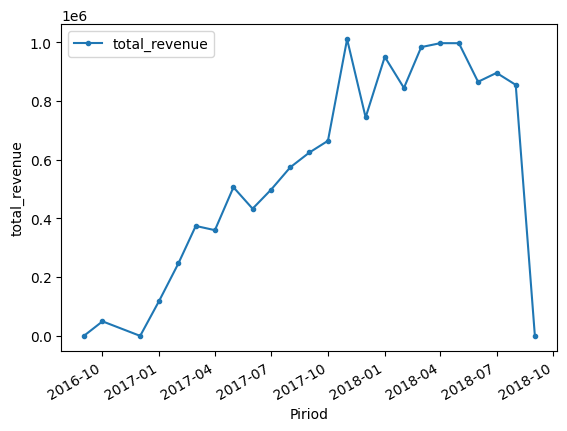

In [4]:
axes = sales_pd.plot(y="total_revenue", style= ".-")
y_label = axes.set_ylabel("total_revenue")
x_label = axes.set_xlabel("Piriod")


##### For the period 2018-10 we observe that the trend line falls directly to 0, which may be due to incomplete data. In this type of case, it would be advisable to remove that record so that it does not damage the model.

In [5]:
sales_pd = sales_pd[:-1]
sales_pd.tail(5)

,total_revenue
month,
2018-04-01,996647.75
2018-05-01,996517.68
2018-06-01,865124.31
2018-07-01,895507.22
2018-08-01,854686.33


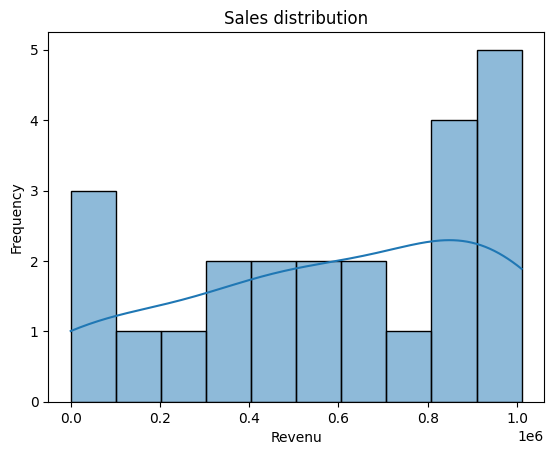

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(sales_pd["total_revenue"], bins=10, kde=True)
plt.title("Sales distribution")
plt.xlabel("Revenu")
plt.ylabel("Frequency")
plt.show()

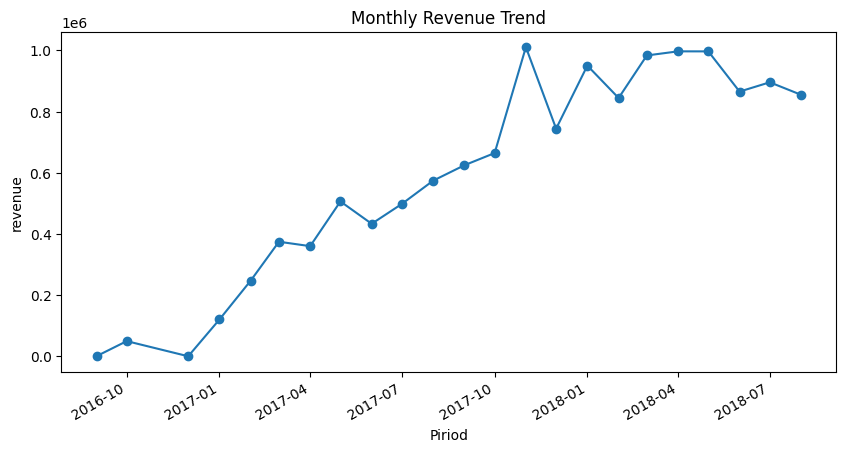

In [7]:
sales_pd["total_revenue"].plot(figsize=(10,5), marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Piriod")
plt.ylabel("revenue")

plt.show()

## Baseline Models

#### Moving Average

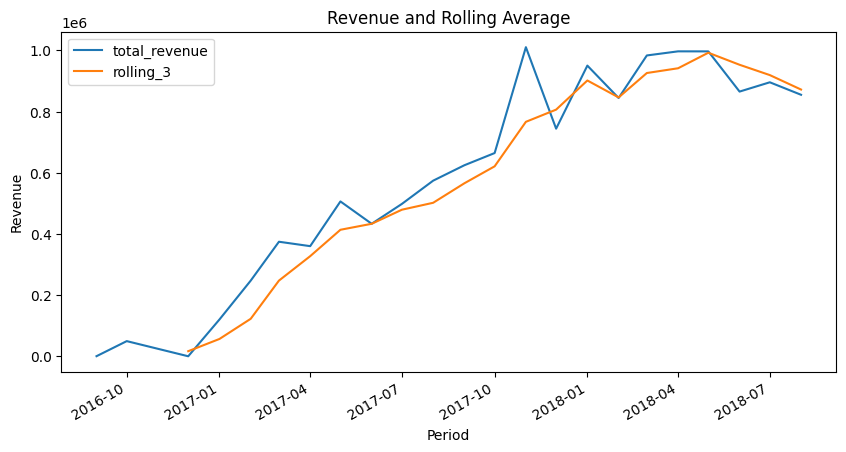

In [8]:
sales_pd["rolling_3"] = (sales_pd["total_revenue"].rolling(window=3).mean())

sales_pd[["total_revenue", "rolling_3"]].plot(figsize=(10,5))
plt.title("Revenue and Rolling Average")
plt.xlabel("Period")
plt.ylabel("Revenue")

plt.show()

#### Exponential Smoothing

In [9]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

exp_model = ExponentialSmoothing(sales_pd["total_revenue"]).fit()
sales_pd["exp_model"] = exp_model.fittedvalues

c:\Professional_project\Virtual_env_project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


#### Holt Linear Trend

In [10]:
from statsmodels.tsa.holtwinters import Holt

holt_model = Holt(sales_pd["total_revenue"]).fit()
sales_pd["holt_model"] = holt_model.fittedvalues

c:\Professional_project\Virtual_env_project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


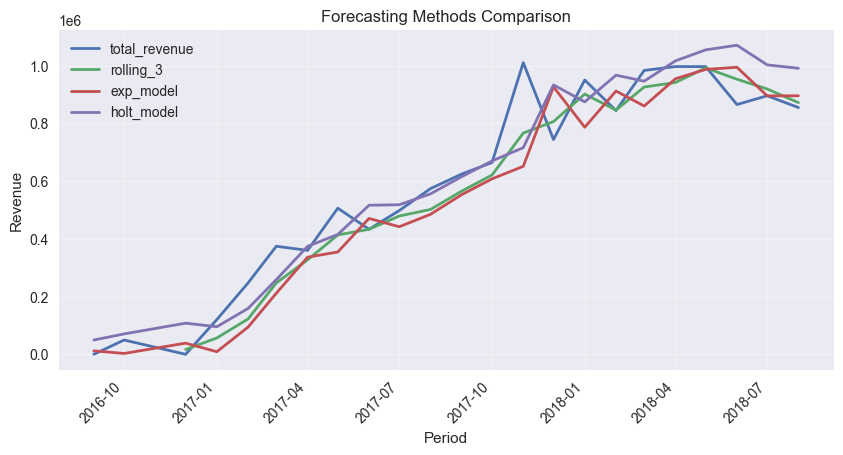

In [11]:
plt.style.use("seaborn-v0_8")
sales_pd[["total_revenue", "rolling_3", "exp_model", "holt_model" ]].plot(figsize=(10,5), marker=None,  linewidth=2)
plt.title("Forecasting Methods Comparison")
plt.xlabel("Period")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.show()

plt.show()